<a href="https://colab.research.google.com/github/heisenberg304/aprendiendo-ml-cloud/blob/semana-5/dia6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:

#importar librerias
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import pandas as pd
#CARGAR DATOS
data = pd.read_csv("/content/drive/MyDrive/data_csv/titanic.csv")


#Manipular datos
#Aplicar mediana para rellenar
data["Age"].fillna(data["Age"].median(), inplace=True)
#Aplicar moda para rellenar
data["Embarked"].fillna(data["Embarked"].mode()[0], inplace=True)
#nuevas features
data["Is_female"] = data["Sex"].map({"female": 1, "male": 0}) #En el contexto del titanic las prioridad era salvar a las mujeres
data["Relatives"] = data["SibSp"] + data["Parch"]
#Encoding para embarked
embarked = pd.get_dummies(data["Embarked"])
#sex = pd.get_dummies(data["Sex"])  #opcion con encoding
#unir las nuevas filas al dataframe principal
data = pd.concat([data, embarked], axis=1)  #pegar dos dataframes uno al lado del otro
#data = pd.concat([data, embarked, sex], axis=1)   #opcion con encoding
#eliminar linea sobrantes:
data = data.drop(["Sex", "PassengerId", "Name", "Ticket", "Cabin", "Embarked"], axis=1)  #para eliminar columnas


#Crear x and y
x = data[["Is_female", "Age", "Pclass", "Fare", "C", "Q",	"S", "Relatives"]] #quitando sibsp y parch el modelo mejora
#x = data[["female", "male", "Age", "Pclass", "Fare", "C", "Q",	"S", "Relatives"]]  #opcion con encoding
y = data["Survived"]
#Separar dataset en train y test
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    random_state = 41,
    test_size = 0.2
)


#crear modelo
model = RandomForestClassifier(n_estimators=77, max_depth=7)
#entrenar el modelo
model.fit(x_train, y_train)
#testear modelo
pred = model.predict(x_test)
#Importancia de cada feature
importances = model.feature_importances_
#otros atributos


#metricas
matrix = confusion_matrix(y_test, pred)
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
#print de metricas
print(f"matrix -> {matrix}")
print(f"accuracy -> {accuracy}")
print(f"precision -> {precision}")
print(f"recall -> {recall}")
print(f"f1 score -> {f1}")
print(f"Importancia = {importances}")

x.head(2)

matrix -> [[100   5]
 [ 23  51]]
accuracy -> 0.8435754189944135
precision -> 0.9107142857142857
recall -> 0.6891891891891891
f1 score -> 0.7846153846153846
Importancia = [0.35889594 0.18602679 0.12779766 0.19794034 0.0161901  0.00848932
 0.01803579 0.08662406]


/tmp/ipykernel_44035/2936076976.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].median(), inplace=True)
/tmp/ipykernel_44035/2936076976.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

,Is_female,Age,Pclass,Fare,C,Q,S,Relatives
0,0,22.0,3,7.2500,False,False,True,1
1,1,38.0,1,71.2833,True,False,False,1


/tmp/ipykernel_5558/1699829651.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].median(), inplace=True)
/tmp/ipykernel_5558/1699829651.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

matrix -> [[90 15]
 [24 50]]
accuracy -> 0.7821229050279329
precision -> 0.7692307692307693
recall -> 0.6756756756756757
f1 score -> 0.7194244604316546
Importancia = [0.40065895 0.16177786 0.15234586 0.19614086 0.00586344 0.00108912
 0.00960819 0.07251572]
Profundidad del arbol = 10
Plot = [Text(0.4873103323699422, 0.9545454545454546, 'x[0] <= 0.5\ngini = 0.469\nsamples = 712\nvalue = [444, 268]'), Text(0.16753973988439305, 0.8636363636363636, 'x[1] <= 6.5\ngini = 0.303\nsamples = 467\nvalue = [380, 87]'), Text(0.3274250361271676, 0.9090909090909092, 'True  '), Text(0.023121387283236993, 0.7727272727272727, 'x[7] <= 3.5\ngini = 0.434\nsamples = 22\nvalue = [7.0, 15.0]'), Text(0.011560693641618497, 0.6818181818181818, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'), Text(0.03468208092485549, 0.6818181818181818, 'x[7] <= 5.5\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'), Text(0.023121387283236993, 0.5909090909090909, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'), Text(0.046242774566473986, 0.59

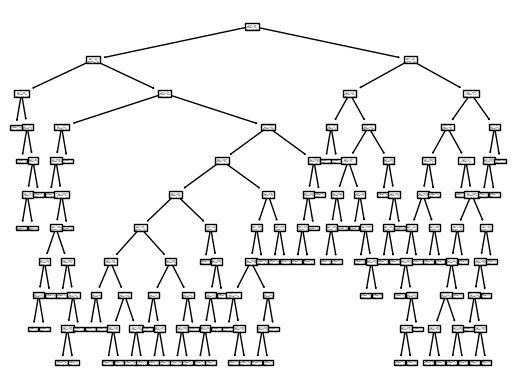

In [ ]:

#importar librerias
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.tree import plot_tree, export_graphviz
#CARGAR DATOS
data = pd.read_csv("/content/drive/MyDrive/data_csv/titanic.csv")


#Manipular datos
#Aplicar mediana para rellenar
data["Age"].fillna(data["Age"].median(), inplace=True)
#Aplicar moda para rellenar
data["Embarked"].fillna(data["Embarked"].mode()[0], inplace=True)
#nuevas features
data["Is_female"] = data["Sex"].map({"female": 1, "male": 0}) #En el contexto del titanic las prioridad era salvar a las mujeres
data["Relatives"] = data["SibSp"] + data["Parch"]
#Encoding para embarked
embarked = pd.get_dummies(data["Embarked"])
#sex = pd.get_dummies(data["Sex"])                 #opcion con encoding
#unir las nuevas filas al dataframe principal
data = pd.concat([data, embarked], axis=1)  #pegar dos dataframes uno al lado del otro
#data = pd.concat([data, embarked, sex], axis=1)   #opcion con encoding
#eliminar linea sobrantes:
data = data.drop(["Sex", "PassengerId", "Name", "Ticket", "Cabin", "Embarked"], axis=1)  #para eliminar columnas


#Crear x and y
x = data[["Is_female", "Age", "Pclass", "Fare", "C", "Q",	"S", "Relatives"]] #quitando sibsp y parch el modelo mejora
#x = data[["female", "male", "Age", "Pclass", "Fare", "C", "Q",	"S", "Relatives"]]  #opcion con encoding
y = data["Survived"]
#Separar dataset en train y test
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    random_state = 42,
    test_size = 0.2
)


#crear modelo
model = DecisionTreeClassifier(max_depth=10)
#entrenar el modelo
model.fit(x_train, y_train)
#testear modelo
pred = model.predict(x_test)
#profundidad del Tree
depth = model.tree_.max_depth
#Importancia de cada feature
importances = model.feature_importances_
#otros atributos
plot = plot_tree(model)
graphviz = export_graphviz(model)


#metricas
matrix = confusion_matrix(y_test, pred)
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
#print de metricas
print(f"matrix -> {matrix}")
print(f"accuracy -> {accuracy}")
print(f"precision -> {precision}")
print(f"recall -> {recall}")
print(f"f1 score -> {f1}")
print(f"Importancia = {importances}")
print(f"Profundidad del arbol = {depth}") #Este valor representa hasta dónde creció el modelo cuando no se limitó su complejidad, lo que suele indicar un escenario de sobreajuste.
print(f"Plot = {plot}")
print(f"Graphviz = {graphviz}")

x.head(2)
